<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Drinkin_Water_Violations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

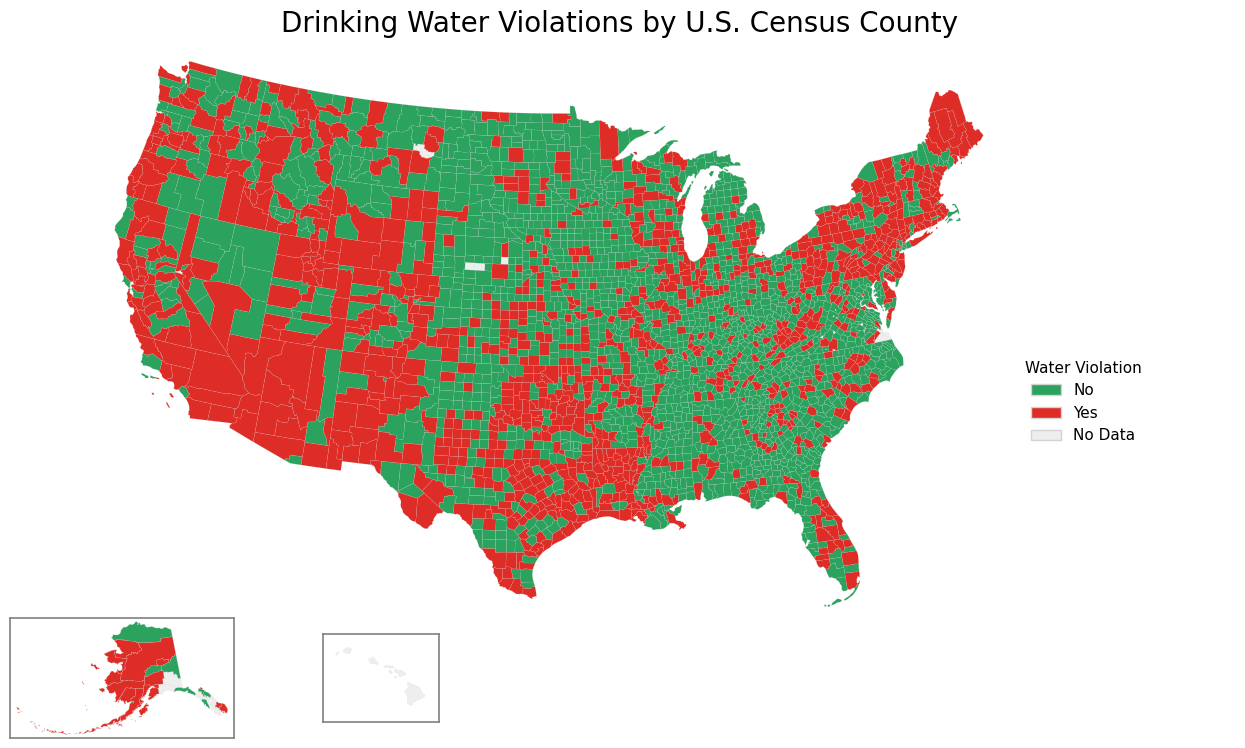

In [2]:
# Open In Colab

# Run Once
# ! pip install geopandas pandas matplotlib numpy openpyxl

import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

file = "/content/2025 County Health Rankings Data - v4.xlsx"

excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

drinking_water = excel_data[[
    "FIPS",
    "State",
    "County",
    "Presence of Water Violation"
]].copy()

# Keep only county rows
drinking_water = drinking_water[drinking_water["County"].notna()].copy()

# Make FIPS match county shapefile GEOID
drinking_water["FIPS"] = (
    drinking_water["FIPS"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Clean violation values so they become Yes / No
raw_vals = drinking_water["Presence of Water Violation"]
numeric_vals = pd.to_numeric(raw_vals, errors="coerce")

drinking_water["water_violation_clean"] = pd.Series(index=drinking_water.index, dtype="object")

# Handle numeric values
drinking_water.loc[numeric_vals == 1, "water_violation_clean"] = "Yes"
drinking_water.loc[numeric_vals == 0, "water_violation_clean"] = "No"

# Handle text values
text_vals = raw_vals.astype(str).str.strip().str.lower()

drinking_water.loc[
    drinking_water["water_violation_clean"].isna() & text_vals.isin(["yes", "y", "true", "1.0"]),
    "water_violation_clean"
] = "Yes"

drinking_water.loc[
    drinking_water["water_violation_clean"].isna() & text_vals.isin(["no", "n", "false", "0.0"]),
    "water_violation_clean"
] = "No"

# Load county shapefile from U.S. Census Bureau
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

# Make sure coordinates are latitude/longitude
counties = counties.to_crs(epsg=4326)

# Merge drinking water data with county map
merged = counties.merge(
    drinking_water,
    left_on="GEOID",
    right_on="FIPS",
    how="left"
)

# Remove U.S. territories only
territory_codes = ["60", "66", "69", "72", "78"]
merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Colors
no_color = "#2ca25f"       # green
yes_color = "#de2d26"      # red
missing_color = "#eeeeee"  # light gray

def plot_violation_map(ax, gdf, linewidth):
    missing = gdf[gdf["water_violation_clean"].isna()]
    no_df = gdf[gdf["water_violation_clean"] == "No"]
    yes_df = gdf[gdf["water_violation_clean"] == "Yes"]

    if not missing.empty:
        missing.plot(
            color=missing_color,
            edgecolor="lightgray",
            linewidth=linewidth,
            ax=ax
        )

    if not no_df.empty:
        no_df.plot(
            color=no_color,
            edgecolor="lightgray",
            linewidth=linewidth,
            ax=ax
        )

    if not yes_df.empty:
        yes_df.plot(
            color=yes_color,
            edgecolor="lightgray",
            linewidth=linewidth,
            ax=ax
        )

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Main Lower 48 map
# Wider map area to reduce right-side white space
ax_main = fig.add_axes([0.02, 0.18, 0.86, 0.75])
plot_violation_map(ax_main, lower48_proj, 0.08)
ax_main.axis("off")

# Alaska inset box
ax_ak = fig.add_axes([0.05, 0.05, 0.19, 0.15])
ax_ak.set_facecolor("white")
plot_violation_map(ax_ak, alaska_proj, 0.12)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.03
y_buffer = (maxy - miny) * 0.03

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Hawaii inset box
ax_hi = fig.add_axes([0.28, 0.07, 0.10, 0.11])
ax_hi.set_facecolor("white")
plot_violation_map(ax_hi, hawaii_proj, 0.12)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Legend
# Moved closer to the map to remove extra right-side white space
ax_leg = fig.add_axes([0.78, 0.36, 0.16, 0.22])
ax_leg.axis("off")

legend_handles = [
    Patch(facecolor=no_color, edgecolor="lightgray", label="No"),
    Patch(facecolor=yes_color, edgecolor="lightgray", label="Yes"),
    Patch(facecolor=missing_color, edgecolor="lightgray", label="No Data")
]

ax_leg.legend(
    handles=legend_handles,
    title="Water Violation",
    loc="center left",
    frameon=False,
    fontsize=11,
    title_fontsize=11
)

# Title
fig.suptitle(
    "Drinking Water Violations by U.S. Census County",
    fontsize=20,
    y=0.96
)

plt.show()